# Livrable 2 — Traitement d'images

Notebook nettoyé et fonctionnel pour le débruitage d'images avec un autoencodeur convolutif.

**Remarques**: ce notebook utilise un pipeline tf.data pour être mémoire-efficient. Ajuste `data_dir`, `MAX_IMAGES` et `BATCH_SIZE` selon ta machine.

In [52]:
# Imports essentiels
import os
import math
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from perlin_noise import PerlinNoise  # pip install perlin-noise
from skimage.metrics import peak_signal_noise_ratio as psnr

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.20.0


## 1) Paramètres et chargement du dataset

Change `data_dir` pour le chemin de ton dossier d'images. Si toutes les images sont dans un seul dossier (pas de sous-classes), on utilise `labels=None` et on gère le split manuellement.

In [53]:
# Paramètres - adapte si nécessaire
data_dir = '/Datasett/train2014'  # <-- adapte ce chemin
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
SEED = 42

# Option pour limiter le dataset pour prototypage (None = utiliser tout)
MAX_IMAGES = 20000  # mettre None pour tout utiliser

# Vérification du chemin
if not os.path.exists(data_dir):
    raise FileNotFoundError(f"Le dossier data_dir n'existe pas: {data_dir}")

In [54]:
# Chargement sans labels (images seules)
raw_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    labels=None,
    label_mode=None,
    shuffle=False,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Convertir nombre de batches en nombre d'images et limiter si demandé
if MAX_IMAGES is not None:
    # nombre de batches nécessaires
    batches_to_keep = math.ceil(MAX_IMAGES / BATCH_SIZE)
    raw_ds = raw_ds.take(batches_to_keep)
    print(f"Limitation activée : ~{batches_to_keep * BATCH_SIZE} images (≈ {MAX_IMAGES} demandé)")
else:
    print("Utilisation de tout le dataset (aucune limitation)")

Found 82783 files.
Limitation activée : ~20000 images (≈ 20000 demandé)


## 2) Split train / validation

On split le dataset déjà chargé (qui est mélangé). Ici 80% train, 20% validation.

In [55]:
# Estimer le nombre de batches et split
total_batches = tf.data.experimental.cardinality(raw_ds).numpy()
if total_batches == tf.data.experimental.INFINITE_CARDINALITY:
    raise RuntimeError('cardinality infinite — vérifie le dataset')

train_batches = int(0.8 * total_batches)
val_batches = total_batches - train_batches

train_ds = raw_ds.take(train_batches)
val_ds = raw_ds.skip(train_batches)

print(f"Batches totaux: {total_batches}, train: {train_batches}, val: {val_batches}")

Batches totaux: 625, train: 500, val: 125


## 3) Normalisation et ajout de bruit (pipeline tf.data)

On normalise dans [0,1] puis on crée deux pipelines : clean et noisy. Le bruit est ajouté de façon vectorisée (pas de conversion complète en NumPy).

In [56]:
# 🔧 Paramètres
NOISE_FACTOR = 0.1
AUTOTUNE = tf.data.AUTOTUNE

# --- Fonctions utilitaires ---
def normalize(images):
    """Normalise les pixels entre 0 et 1."""
    return tf.cast(images, tf.float32) / 255.0

def add_gaussian_noise(image):
    """Ajoute du bruit gaussien à une image donnée."""
    noise = tf.random.normal(shape=tf.shape(image), mean=0.0, stddev=1.0)
    noisy = image + NOISE_FACTOR * noise
    noisy = tf.clip_by_value(noisy, 0.0, 1.0)
    return noisy

def make_denoising_dataset(dataset):
    """
    Crée un dataset (entrée bruitée, cible propre) cohérent image par image.
    Chaque élément retourné est (image_bruitee, image_propre).
    """
    dataset = dataset.map(lambda x: normalize(x), num_parallel_calls=AUTOTUNE)
    dataset = dataset.map(lambda x: (add_gaussian_noise(x), x), num_parallel_calls=AUTOTUNE)
    dataset = dataset.cache().prefetch(AUTOTUNE)
    return dataset

In [57]:
# --- Création des datasets cohérents ---
train_dataset = make_denoising_dataset(train_ds)
val_dataset = make_denoising_dataset(val_ds)

In [58]:
# --- Vérification rapide ---
for noisy_imgs, clean_imgs in train_dataset.take(1):
    print("Batch bruité :", noisy_imgs.shape)
    print("Batch propre :", clean_imgs.shape)


Batch bruité : (32, 128, 128, 3)
Batch propre : (32, 128, 128, 3)


## 4) Visualisation : quelques images propres vs bruitées

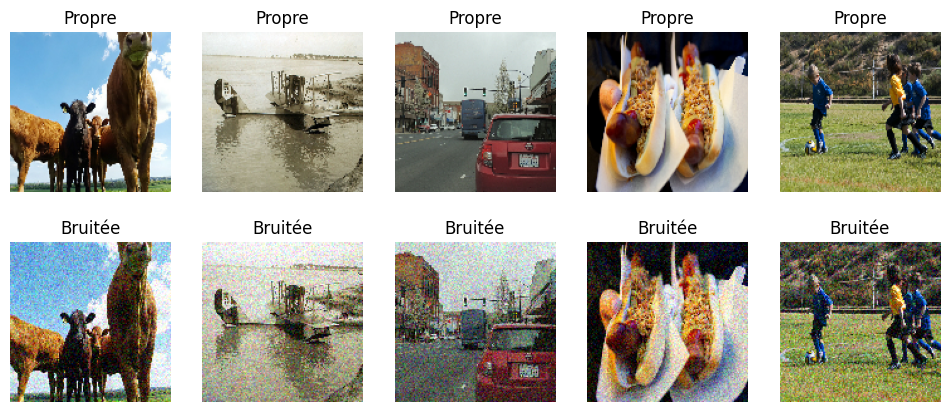

In [59]:
# --- Visualisation cohérente ---
def show_examples(dataset, n=5):
    """
    Affiche n images bruitées et leur équivalent propre à partir du même dataset.
    """
    noisy_batch, clean_batch = next(iter(dataset))
    plt.figure(figsize=(12, 5))
    for i in range(n):
        # Image propre
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(clean_batch[i].numpy())
        plt.title('Propre')
        plt.axis('off')

        # Image bruitée
        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(noisy_batch[i].numpy())
        plt.title('Bruitée')
        plt.axis('off')

    plt.show()

# Exemple d'affichage
show_examples(val_dataset, n=5)

## 5) Modèle : Autoencodeur convolutif

Modèle simple, à améliorer si besoin.

In [60]:
from tensorflow.keras import layers, models

autoencoder = models.Sequential([
    # --- ENCODEUR ---
    layers.Input(shape=(128, 128, 3)),
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2), padding='same'),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2), padding='same'),
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2), padding='same'),

    # --- DÉCODEUR ---
    layers.Conv2DTranspose(128, (3,3), strides=2, activation='relu', padding='same'),
    layers.Conv2DTranspose(64, (3,3), strides=2, activation='relu', padding='same'),
    layers.Conv2DTranspose(32, (3,3), strides=2, activation='relu', padding='same'),
    layers.Conv2D(3, (3,3), activation='sigmoid', padding='same')
])

autoencoder.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                    loss='mse')


## 6) Entraînement

On calcule `steps_per_epoch` pour éviter d'attendre l'épuisement complet des datasets si nécessaire.

In [ ]:
EPOCHS = 20

# Calculer steps par epoch
train_steps = tf.data.experimental.cardinality(train_dataset).numpy()
val_steps = tf.data.experimental.cardinality(val_dataset).numpy()
print('Train steps (batches):', train_steps, 'Val steps (batches):', val_steps)

history = autoencoder.fit(
    train_dataset,
    epochs=EPOCHS,
    steps_per_epoch=train_steps,
    validation_data=val_dataset,
    validation_steps=val_steps
)

Train steps (batches): 500 Val steps (batches): 125
Epoch 1/20
271/500 ━━━━━━━━━━━━━━━━━━━━ 1:22 359ms/step - loss: 0.0649

## 7) Évaluation : affichage et métrique PSNR

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step


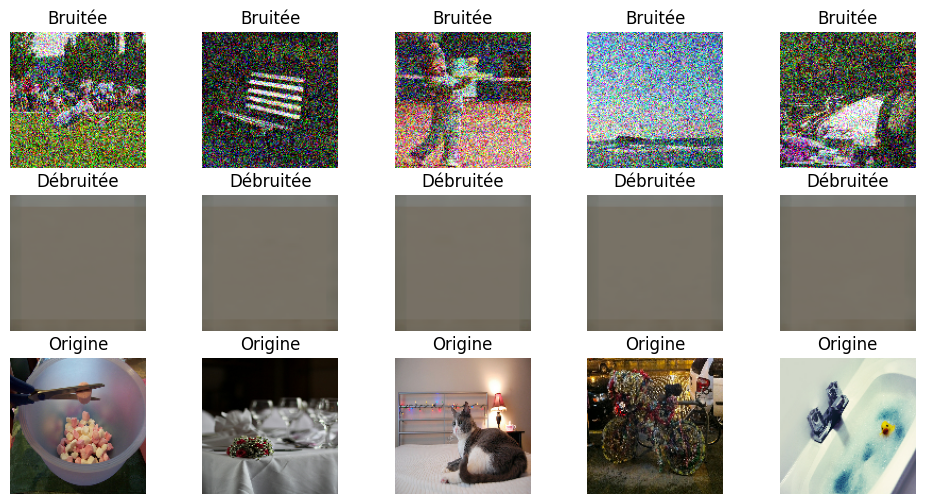

PSNR (moyenne sur batch): 11.169949588219664


In [13]:
# Prédictions sur un batch de validation
noisy_batch, clean_batch = next(iter(val_dataset))
preds = autoencoder.predict(noisy_batch)

# Affichage
n = min(5, noisy_batch.shape[0])
plt.figure(figsize=(12,6))
for i in range(n):
    ax = plt.subplot(3, n, i+1)
    plt.imshow(noisy_batch[i].numpy())
    plt.title('Bruitée')
    plt.axis('off')

    ax = plt.subplot(3, n, i+1+n)
    plt.imshow(preds[i])
    plt.title('Débruitée')
    plt.axis('off')

    ax = plt.subplot(3, n, i+1+2*n)
    plt.imshow(clean_batch[i].numpy())
    plt.title('Origine')
    plt.axis('off')
plt.show()

# Calcul PSNR moyen (sur ce batch)
psnr_values = [psnr(clean_batch[i].numpy(), preds[i]) for i in range(n)]
print('PSNR (moyenne sur batch):', sum(psnr_values)/len(psnr_values))